In [140]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec
from tabulate import tabulate

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [241]:
## FUNCTIONS ##

def plotting_style():
    plt.style.use('seaborn-poster') # ggplot
    params = {'axes.labelsize': 30,
            'axes.titlesize': 25,
            'legend.fontsize': 25,
            'xtick.labelsize': 25,
            'ytick.labelsize': 25,
            # 'figure.figsize': (10,5),
            'font.weight': 'regular',
            # 'font.size': 'regular',
            'font.family': 'sans-serif',
            'lines.markersize': 20,
            'font.serif': 'Helvetica Neue',
            'lines.linewidth': 4,
            'axes.grid': False,
            'axes.spines.top': False,
            'axes.spines.right': False}
    plt.rcParams.update(params)
    sns.set_context(rc={'lines.markeredgewidth': 0.1})
    np.set_printoptions(formatter={'float_kind':'{:f}'.format})

def load_data(
    fdir,
    assessments=['Parent', 'Child', 'Teacher'],
    data_type='preprocessed'
    ):
    """loads all response data for healthy brain network
    Args:
        assessments (list of str): default is all assessments ['Parent', 'Child', 'Teacher']
        data_type (str): default is 'preprocessed'. other option is 'raw'
    Returns:
        df_data_all (pd dataframe): all response data;
        df_diagnosis (pd dataframe): diagnosis data for each participant
    """
    
    # get data
    df_data_all = pd.DataFrame()
    for assessment in assessments:
        # load csv
        df_data = pd.read_csv(os.path.join(fdir, f'{assessment}-features-{data_type}.csv'))
        df_data.columns = df_data.columns.str.replace('numeric__', '')
        df_data_all = pd.concat([df_data, df_data_all], axis=1)

    # delete duplicate columns
    data = df_data_all.loc[:,~df_data_all.columns.duplicated()].copy()
    
    return data


def load_diagnosis(fdir):
    demo_dict = {
                'Identifiers': 'Identifiers',
                'Sex': 'Sex',
                'Age': 'Age', 
                'PreInt_Demos_Fam,Child_Race_cat': 'Race',
                'PreInt_Demos_Fam,Child_Ethnicity_cat': 'Ethnicity',
                'Enroll_Year': 'Enroll_Year',
                'Site': 'Site',
                'comorbidities': 'comorbidities',
                }

    # get clinical diagnosis
    diagnosis = pd.read_csv(os.path.join(fdir, 'Clinical_Diagnosis_Demographics.csv'))

    # get columns to filter dataframe
    cols = []
    for num in range(1,11):

        num_str = str(num).zfill(2)
        col_1 = f'DX_{num_str}_Cat_new'
        col_2 = col_1.replace('_Cat_new', '')
        cols.extend([col_1, col_2])

    cols_to_keep = list(demo_dict.values())
    cols_to_keep.extend(cols)

    diagnosis = diagnosis.rename(columns=demo_dict)[cols_to_keep]   
    diagnosis['Category'] = diagnosis['DX_01_Cat_new']
    diagnosis['Diagnosis'] = diagnosis['DX_01']
    
    return diagnosis

def filter_data(
    data, 
    diagnosis, 
    remove_demos=False, 
    col_to_filter='Category_raw', 
    val_to_filter=['ADHD'],
    drop_identifiers=True
    ):
    """filters `data` based on information in `diagnosis`
    
    Args:
        data (pd dataframe): `data` output from `load_data`
        diagnosis (pd dataframe): `diagnosis` output from `load_data`
        remove_demos (bool): optionally remove columns corresponding to demographic information (e.g., Sex, Race, Age) and just leave questionnaire response data
        col_filter (str or None): filter `data` using `col_to_filter`(e.g., column name)
        val_to_filter (list of str or None): filter `data` using `val_to_filter` (eg., value in column) from `diagnosis`
        drop_identifiers (bool): drop 'Identifiers' column
    """
    
    for col in diagnosis.columns:
        if col != "Identifiers":
          diagnosis = diagnosis.rename(columns={col: f'{col}_raw'})
    
    df_data_diagnosis = data.merge(diagnosis, on='Identifiers')
    
    # filter based on some conditional
    col_to_filter_raw = f'{col_to_filter}_raw'
    if (col_to_filter_raw is not None) and (val_to_filter is not None):
        data_out = df_data_diagnosis[df_data_diagnosis[col_to_filter_raw].isin(val_to_filter)].reset_index(drop=True)
    else:
        data_out = df_data_diagnosis.reset_index(drop=True)

    # optionally remove demographic data (sex, age, comorbidities etc.)
    demo_cols = [col for col in diagnosis.columns if 'Identifiers' not in col]
    if remove_demos:
        # exclude demo variables from dataset
        demo_cols_stripped = [col.replace('_raw', '') for col in demo_cols]
        data_out = data_out[data_out.columns[~data_out.columns.isin(demo_cols_stripped)]]
    
    # optionally drop identifiers
    if drop_identifiers:
        data_out = data_out[[col for col in data_out.columns if 'Identifiers' not in col]]

    # columns to include in the modeling process (only response data)
    cols_to_keep = [col for col in data_out.columns if '_raw' not in col]
    cols_to_keep.remove('Identifiers')

    return data_out, cols_to_keep


def get_comorbidities(dataframe,
                     comorbid_disorders=['Anxiety Disorders', 'Depressive Disorders', 'ADHD', 'Autism Spectrum Disorder']
                     ):

    vals = []; categories = []; diagnoses = []; percent_all=[]
    for num in np.arange(1,11):
        for disorder in comorbid_disorders:

            num_str = str(num).zfill(2)
            disorder_num = f'DX_{num_str}_Cat_new'

            val = np.nansum(dataframe[disorder_num].str.contains(disorder))
            percent = (val / dataframe.shape[0]) *100
            vals.append(val)
            percent_all.append(percent)
            diagnoses.append(disorder)
            categories.append(disorder_num)

    # make dataframe
    df_co = pd.DataFrame()
    df_co['Diagnosis'] = diagnoses
    df_co['Count'] = vals
    df_co['Percent'] = percent_all
    df_co['Category'] = categories
    df_co['Diagnosis Categories'] = df_co['Category'].str.extract('(\d+)')

    return df_co

def count_all_diagnoses(dataframe, diagnosis='ADHD'):

    count_all = []; diagnosis_categories=[]
    for idx in range(1,11):

        num_str = str(idx).zfill(2)
        disorder_str = f'DX_{num_str}_Cat_new'

        count = sum(dataframe[disorder_str]==diagnosis)

        diagnosis_categories.append(disorder_str)
        count_all.append(count)

    df = pd.DataFrame()
    df['count'] = count_all
    df['diagnosis_categories'] = diagnosis_categories
    df['primary_diagnosis'] = diagnosis

    return df


In [243]:
### SET DATA DIRECTORY ###
fdir = '/Users/maedbhking/Documents/hbn_data' # where data are saved

### Set Variables ###
diagnosis_name = 'Specific Learning Disorder with Impairment in Reading'
no_diagnosis_name = 'No Diagnosis Given'

### load data ###
df_data_all = load_data(fdir,
                        assessments=['Parent', 'Child', 'Teacher'], 
                        data_type='preprocessed')

### load diagnosis ###
df_diagnosis = load_diagnosis(fdir)


### filter data ###
data, cols_to_keep = filter_data(
                    data=df_data_all, 
                    diagnosis=df_diagnosis, 
                    remove_demos=True, 
                    col_to_filter='Category', 
                    val_to_filter=[diagnosis_name, no_diagnosis_name],
                    drop_identifiers=False
                    )

# remove '_raw' suffix
data.columns = [col.replace('_raw', '') for col in data.columns]


In [4]:
### summary stats ###

sample_size = df_diagnosis.shape[0]
print(f'total sample size of healthy brain network dataset is {sample_size}\n')

diagnosis = df_diagnosis[df_diagnosis['Diagnosis']==diagnosis_name]
no_diagnosis = df_diagnosis[df_diagnosis['Diagnosis']==no_diagnosis_name]

num_diagnosis = len(diagnosis)
num_no_diagnosis = len(no_diagnosis)
print(f'there are {num_diagnosis} participants with a primary diagnosis of {diagnosis_name} and {num_no_diagnosis} with {no_diagnosis_name}\n')

# print out summaries
for diagnosis in [diagnosis_name, no_diagnosis_name]:
    print(f'PARTICIPANTS WITH {diagnosis}')
    
    tmp = df_diagnosis[df_diagnosis['Diagnosis']==diagnosis]
    
    sex = tmp['Sex'].value_counts()
    print(f'1. there are {sex.male} males and {sex.female} females\n')
    
    num_sites = len(tmp['Site'].unique())
    sites = tmp['Site'].value_counts()
    site_numbers = sites.index.tolist()
    site_count = sites.tolist()
    print(f'3. there are {num_sites} study sites and following # of participants collected across the following sites are {site_count}: {site_numbers}\n')

    years = tmp['Enroll_Year'].value_counts().index.astype(str).str.strip('.0').astype(int).tolist()
    num_years = len(tmp['Enroll_Year'].unique())
    print(f'4. data were collected across {num_years} years: {years}\n')

    ages_6_10 = len(tmp[tmp['Age'].round()<=10])
    ages_10_21 = len(tmp[tmp['Age'].round()>10])
    print(f'2. there are {ages_6_10} children ages 6-10 and {ages_10_21} children ages 11-21\n')

    comorbid = round((tmp['comorbidities'].value_counts() / len(tmp)) * 100)
    num_comorbid = comorbid[1:].sum()
    print(f'6. approximately {num_comorbid}% have disorder combordities\n')



total sample size of healthy brain network dataset is 4767

there are 285 participants with Specific Learning Disorder with Impairment in Reading and 373 with No Diagnosis Given

PARTICIPANTS WITH Specific Learning Disorder with Impairment in Reading
1. there are 153 males and 132 females

3. there are 5 study sites and following # of participants collected across the following sites are [111, 101, 70, 2, 1]: [4, 1, 3, 5, 2]

4. data were collected across 8 years: [2019, 2018, 202, 2017, 2021, 2016, 2015, 2022]

2. there are 199 children ages 6-10 and 86 children ages 11-21

6. approximately 70.0% have disorder combordities

PARTICIPANTS WITH No Diagnosis Given
1. there are 198 males and 175 females

3. there are 5 study sites and following # of participants collected across the following sites are [223, 75, 68, 4, 3]: [1, 3, 4, 2, 5]

4. data were collected across 8 years: [2017, 2016, 2019, 2018, 202, 2021, 2015, 2022]

2. there are 229 children ages 6-10 and 144 children ages 11-21


<Figure size 1280x880 with 0 Axes>

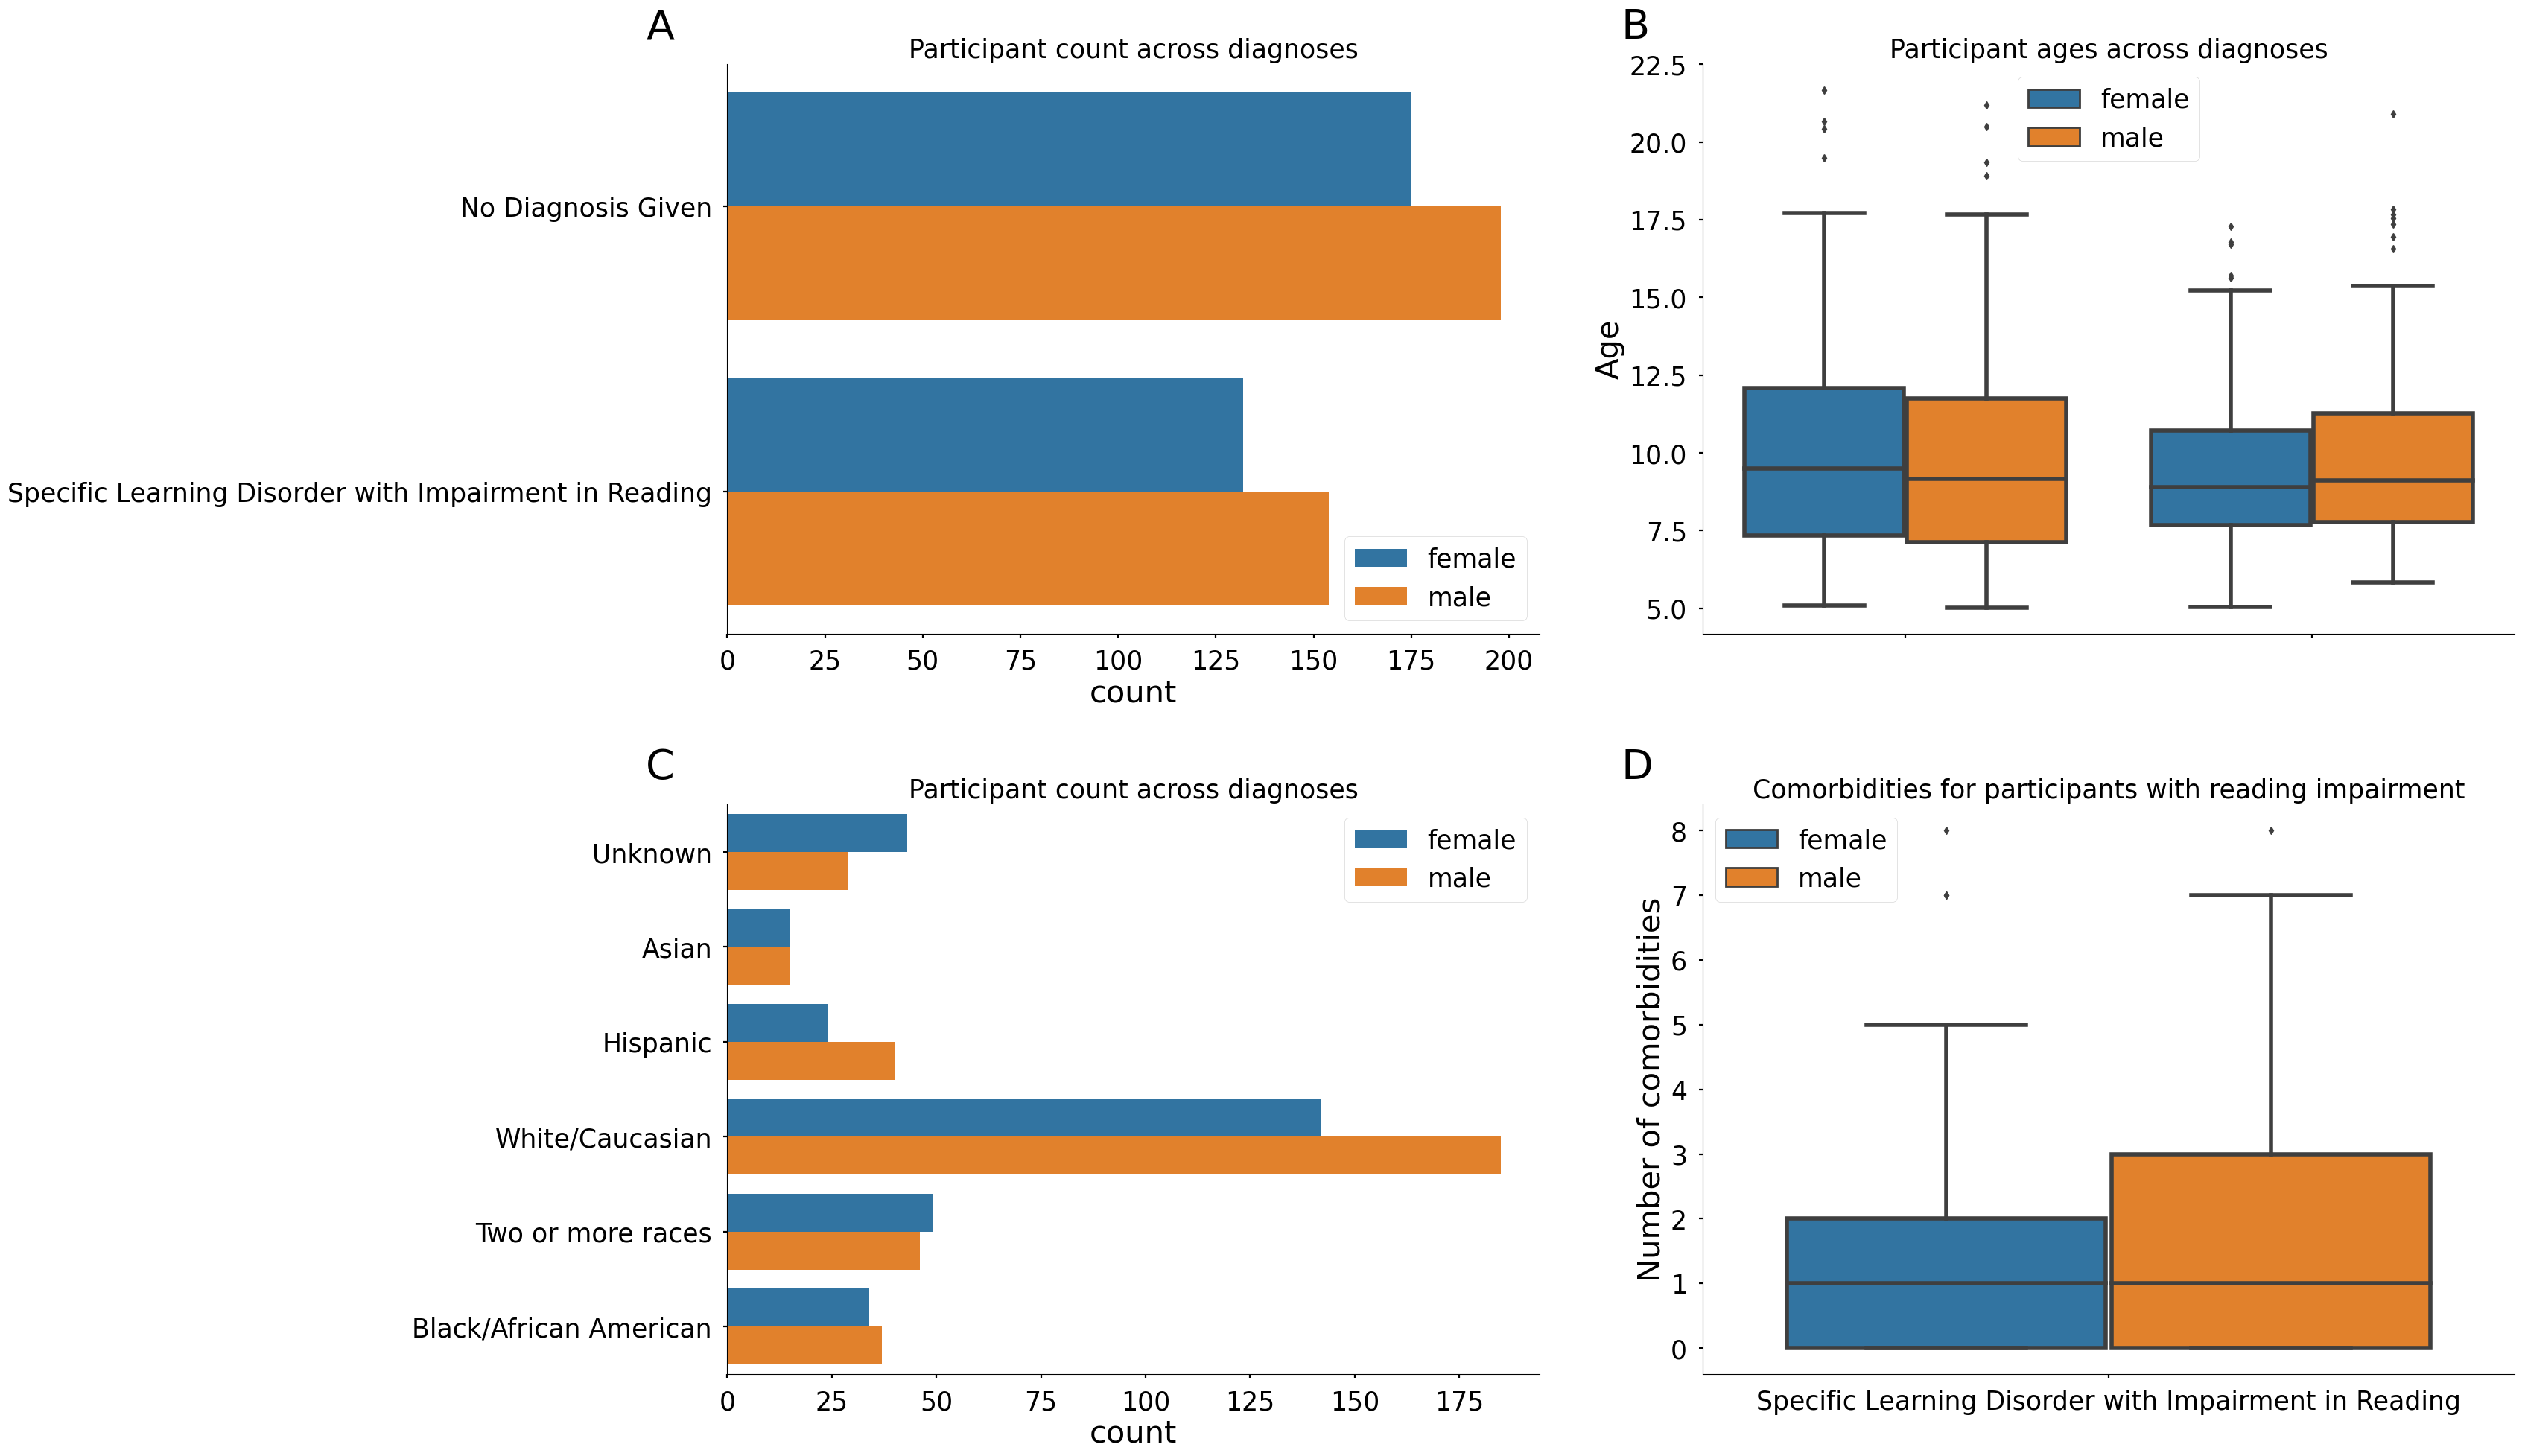

In [178]:
plt.clf()
plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 40

fig = plt.figure()
gs = GridSpec(2, 2, figure=fig)

ax = fig.add_subplot(gs[0,0])
ax = sns.countplot(data=data, y='Category', hue='Sex', ax=ax)
ax.set_ylabel('')
ax.set_title('Participant count across diagnoses')
ax.text(x_pos, y_pos, 'A', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)

ax = fig.add_subplot(gs[0,1])
#ax = sns.violinplot(x='Category', y='Age', hue='Sex', split=True, data=data, ax=ax)
ax = sns.boxplot(x='Category', y='Age', hue='Sex', data=data, ax=ax)
plt.xticks(rotation=45, ha='right');
ax.set_xticklabels('')
ax.set_xlabel('')
ax.set_title('Participant ages across diagnoses')
ax.text(x_pos, y_pos, 'B', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)

ax = fig.add_subplot(gs[1,0])
tmp = data[data['Race'].isin(['Unknown', 'Hispanic', 'Two or more races', 'Asian',
       'Black/African American', 'White/Caucasian'])]
ax = sns.countplot(data=tmp, y='Race', hue='Sex', ax=ax)
ax.set_ylabel('')
ax.set_title('Participant count across diagnoses')
ax.text(x_pos, y_pos, 'C', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)


ax = fig.add_subplot(gs[1,1])
tmp = data[data['Category']==diagnosis_name]
ax = sns.boxplot(x='Category', y='comorbidities', hue='Sex', data=tmp, ax=ax)
ax.set_ylabel('Number of comorbidities')
ax.set_xlabel('')
ax.set_title('Comorbidities for participants with reading impairment')
ax.text(x_pos, y_pos, 'D', transform=ax.transAxes, fontsize=labelsize, verticalalignment='top')
ax.legend_.set_title(None)

plt.subplots_adjust(left=0.125, bottom=0.001, right=2.0, top=2.0, wspace=.2, hspace=.3)

#save_path = os.path.join(dirs.figure, f'fig1.svg')
#plt.savefig(save_path, bbox_inches="tight", dpi=300)

In [166]:
# load clinical data
dx = pd.read_csv(os.path.join(fdir, 'Clinical_Diagnosis_Demographics.csv'))

# get dataframes
df_primary = dx[dx['DX_01_Cat_new']==diagnosis_name]
df_not_primary = dx[dx['DX_02_Cat_new']==diagnosis_name]

# get comorbidities
df_co = get_comorbidities(dataframe=df_primary,
                          comorbid_disorders=['Anxiety Disorders', 'Depressive Disorders', 'ADHD', 'Autism Spectrum Disorder']
                          )


tmp = df_co[df_co['Category']!='DX_01_Cat_new']
fig = px.bar(tmp, 
             y="Diagnosis", 
              x="Count", 
             color="Diagnosis Categories", 
             orientation='h',
             title=f'Comorbidities of {diagnosis_name}')
fig.update_layout({'plot_bgcolor': 'rgba(0,0,0,0)'})
fig.show()

## Count participants with a primary, secondary, tertiary (etc) diagnosis of Reading Impairment

+---------+----------------------+-------------------------------------------------------+
|   Count |   Diagnosis Category | Diagnosis                                             |
+=========+======================+=======================================================+
|     286 |                   01 | Specific Learning Disorder with Impairment in Reading |
+---------+----------------------+-------------------------------------------------------+
|     247 |                   02 | Specific Learning Disorder with Impairment in Reading |
+---------+----------------------+-------------------------------------------------------+
|     172 |                   03 | Specific Learning Disorder with Impairment in Reading |
+---------+----------------------+-------------------------------------------------------+
|      61 |                   04 | Specific Learning Disorder with Impairment in Reading |
+---------+----------------------+-------------------------------------------------------+

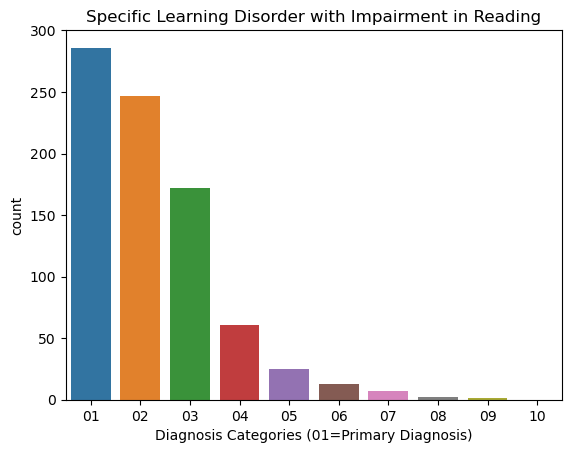

In [127]:

count_df = count_all_diagnoses(dataframe=dx, diagnosis=diagnosis_name)
count_df['diagnosis_categories'] = count_df['diagnosis_categories'].str.replace('_Cat_new', '').str.replace('DX_', '')

sns.barplot(data=count_df, x='diagnosis_categories', y='count')
plt.xlabel('Diagnosis Categories (01=Primary Diagnosis)')
plt.title(diagnosis_name)

head = ['Count', 'Diagnosis Category', 'Diagnosis']
print(tabulate(np.array(count_df), headers=head, tablefmt="grid"))

## Year of Enrollment

<Figure size 1280x880 with 0 Axes>

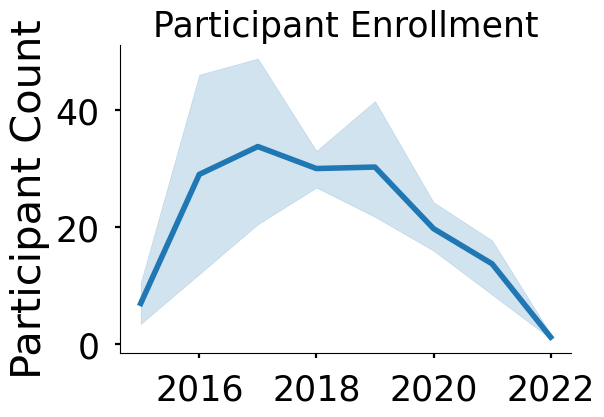

In [230]:
plt.clf()
vis.plotting_style()
x_pos = -0.1
y_pos = 1.1
labelsize = 40

fig = plt.figure()
gs = GridSpec(2, 2, figure=fig)

tmp = data.groupby(
    ['Enroll_Year', 'Category', 'Sex']).count()[['Identifiers']].reset_index().rename(
    {'Identifiers': 'Participant Count'}, axis=1)

ax = fig.add_subplot(gs[0,0])
ax = sns.lineplot(data=tmp, x='Enroll_Year', y='Participant Count', ax=ax)
ax.set_xlabel('')
ax.set_title('Participant Enrollment');

In [107]:
tmp = data.groupby(
    ['Enroll_Year', 'Category', 'Sex']).count()[['Identifiers']].reset_index().rename(
    {'Identifiers': 'Participant Count'}, axis=1)

head = ['Enrollment Year', 'Diagnosis', 'Sex', '# of Participants']
print(tabulate(np.array(tmp), headers=head, tablefmt="grid"))

+-------------------+-------------------------------------------------------+--------+---------------------+
|   Enrollment Year | Diagnosis                                             | Sex    |   # of Participants |
+===================+=======================================================+========+=====================+
|              2015 | No Diagnosis Given                                    | female |                  12 |
+-------------------+-------------------------------------------------------+--------+---------------------+
|              2015 | No Diagnosis Given                                    | male   |                   9 |
+-------------------+-------------------------------------------------------+--------+---------------------+
|              2015 | Specific Learning Disorder with Impairment in Reading | female |                   4 |
+-------------------+-------------------------------------------------------+--------+---------------------+
|              2015

## Participant Count

In [208]:
tmp = data.groupby(
    ['Category', 'Sex']).count()[['Identifiers']].reset_index().rename(
    {'Identifiers': 'Participant Count'}, axis=1)

head = ['Diagnosis', 'Sex', '# of Participants']
print(tabulate(np.array(tmp), headers=head, tablefmt="grid"))


+-------------------------------------------------------+--------+---------------------+
| Diagnosis                                             | Sex    |   # of Participants |
+=======================================================+========+=====================+
| No Diagnosis Given                                    | female |                 175 |
+-------------------------------------------------------+--------+---------------------+
| No Diagnosis Given                                    | male   |                 198 |
+-------------------------------------------------------+--------+---------------------+
| Specific Learning Disorder with Impairment in Reading | female |                 132 |
+-------------------------------------------------------+--------+---------------------+
| Specific Learning Disorder with Impairment in Reading | male   |                 154 |
+-------------------------------------------------------+--------+---------------------+


## Age

In [215]:
tmp = data.groupby(
    ['Category', 'Sex'])['Age'].agg(
    {'mean', 'std'}).reset_index().rename(
    {'mean': 'age (mean)', 'std': 'age (std)'}, axis=1)

head = ['Diagnosis', 'Sex', 'age (mean)', 'age (std)']
print(tabulate(np.array(tmp), headers=head, tablefmt="grid"))

+-------------------------------------------------------+--------+--------------+-------------+
| Diagnosis                                             | Sex    |   age (mean) |   age (std) |
+=======================================================+========+==============+=============+
| No Diagnosis Given                                    | female |     10.1169  |     3.55391 |
+-------------------------------------------------------+--------+--------------+-------------+
| No Diagnosis Given                                    | male   |      9.75773 |     3.38882 |
+-------------------------------------------------------+--------+--------------+-------------+
| Specific Learning Disorder with Impairment in Reading | female |      9.46728 |     2.53514 |
+-------------------------------------------------------+--------+--------------+-------------+
| Specific Learning Disorder with Impairment in Reading | male   |      9.94386 |     2.9375  |
+---------------------------------------

## Race/Ethnicity

In [209]:
tmp = data[data['Race'].isin(['Unknown', 'Hispanic', 'Two or more races', 'Asian',
       'Black/African American', 'White/Caucasian'])]

tmp = data.groupby(
    ['Race', 'Sex']).count()[['Identifiers']].reset_index().rename(
    {'Identifiers': 'Participant Count'}, axis=1)

head = ['Race/Ethnicity', 'Sex', '# of Participants']
print(tabulate(np.array(tmp), headers=head, tablefmt="grid"))


+------------------------+--------+---------------------+
| Race/Ethnicity         | Sex    |   # of Participants |
+========================+========+=====================+
| Asian                  | female |                  15 |
+------------------------+--------+---------------------+
| Asian                  | male   |                  15 |
+------------------------+--------+---------------------+
| Black/African American | female |                  34 |
+------------------------+--------+---------------------+
| Black/African American | male   |                  37 |
+------------------------+--------+---------------------+
| Hispanic               | female |                  24 |
+------------------------+--------+---------------------+
| Hispanic               | male   |                  40 |
+------------------------+--------+---------------------+
| Two or more races      | female |                  49 |
+------------------------+--------+---------------------+
| Two or more 

## Comorbidities

In [211]:
tmp = data.groupby(
    ['Category', 'Sex'])['comorbidities'].agg(
    {'mean', 'std'}).reset_index().rename(
    {'mean': 'mean (comorbidities)', 'std': 'std (comorbidities)'}, axis=1)

head = tmp.columns.tolist()
print(tabulate(np.array(tmp), headers=head, tablefmt="grid"))

+-------------------------------------------------------+--------+------------------------+-----------------------+
| Category                                              | Sex    |   mean (comorbidities) |   std (comorbidities) |
+=======================================================+========+========================+=======================+
| No Diagnosis Given                                    | female |                0       |               0       |
+-------------------------------------------------------+--------+------------------------+-----------------------+
| No Diagnosis Given                                    | male   |                0       |               0       |
+-------------------------------------------------------+--------+------------------------+-----------------------+
| Specific Learning Disorder with Impairment in Reading | female |                1.53788 |               1.57463 |
+-------------------------------------------------------+--------+------

## UMAP Visualization 

In [330]:
data, cols_to_keep = filter_data(
                    data=df_data_all, 
                    diagnosis=df_diagnosis, 
                    remove_demos=False, 
                    col_to_filter='Category', 
                    val_to_filter=['Specific Learning Disorder with Impairment in Reading'],
                    drop_identifiers=True
                    )

In [331]:
import umap

### SET VARIABLES HERE ###
n_neighbors = 15
n_components = 5
metric = 'euclidean'
min_dist = 0.0

# data
data_to_transform = data[cols_to_keep].select_dtypes(include=np.number)
 
umap_embeddings = umap.UMAP(n_neighbors=n_neighbors, 
                        n_components=n_components, 
                        metric=metric,
                        min_dist=min_dist).fit_transform(data_to_transform)

In [332]:
import hdbscan

### SET VARIABLES ###
min_cluster_size = 15
metric = 'euclidean' # cosine
cluster_selection_method = 'eom'

# get clusters
clusters = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                        metric=metric,                      
                        cluster_selection_method=cluster_selection_method).fit(umap_embeddings)

In [333]:
# Visualize UMAP

import plotly.express as px

### SET VARIABLES ###
n_components = 2
n_neighbors = 15
metric = 'euclidean' # cosine
min_dist = 0.0
add_cols = ['Sex_raw', 'Diagnosis_raw', 'Category_raw', 'comorbidities_raw']
hover_data = ['Sex_raw', 'Diagnosis_raw', 'Category_raw', 'comorbidities_raw', 'labels']
color = 'labels'

# data
data_to_transform = data[cols_to_keep].select_dtypes(include=np.number)

umap_embeddings_reduced = umap.UMAP(n_neighbors=n_neighbors, 
                        n_components=n_components, 
                        metric=metric,
                        min_dist=min_dist).fit_transform(data_to_transform)

# 2D or 3D visualization?
if n_components==3:
    df = pd.DataFrame(umap_embeddings_reduced, columns=['x', 'y', 'z'])
elif n_components==2:
     df = pd.DataFrame(umap_embeddings_reduced, columns=['x', 'y'])
df['labels'] = clusters.labels_

# add demo data back in
df[add_cols] = data[add_cols]

# don't plot participants who weren't assigned to a cluster
df = df.loc[(df.labels != -1), :]

# visualize the interactive plot
if n_components==2:
    fig = px.scatter(df, 'x', 'y', color=color, hover_data=hover_data) # size='Size',
elif n_components==3:
    fig = px.scatter_3d(df, x='x', y='y', z='z', color=color, hover_data=hover_data)

fig.update_layout({'plot_bgcolor': 'rgba(0,0,0,0)',
              'paper_bgcolor': 'rgba(0,0,0,0)'})
fig.show()